In [97]:
import sys
sys.path.append('C:\\aiproject')

import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from dataclasses import dataclass
from scipy.stats import zscore
import scipy.stats as stats
from tqdm import tqdm

# PyTorch 관련
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import pickle

import notebook.feature.WF_feature_selection as wf_fs
import notebook.feature.feature_engineering as feat_eng


In [98]:
BASE_DIR = Path.cwd().resolve().parent.parent

In [99]:
DATA_DIR = BASE_DIR / "data"
MODEL_DIR = BASE_DIR / "model"
RESULTS_DIR = BASE_DIR / "results" / "DL"
NOTEBOOK_DIR = BASE_DIR / "notebook" / "DL"
OUTPUT_DIR = DATA_DIR / "output"
FEATURE_DIR = DATA_DIR / "recommand_features"

MODEL_SAVE_DIR = MODEL_DIR
SCALER_SAVE_DIR = MODEL_DIR

RESULTS_SAVE_DIR = RESULTS_DIR
PLOTS_SAVE_DIR = RESULTS_DIR / "plots"
METRICS_SAVE_DIR = RESULTS_DIR / "metrics"

In [100]:
MODE_CONFIGS = {
    "toc": {  # TOC_VU 단일 예측 - 그리드 탐색 최적 
        "hidden_size": 512,  
        "num_layers": 1,
        "dropout": 0.2,    
        "learning_rate": 1e-3,  
        "batch_size": 1024,  
        "window_size": 48,  
        "output_size": 1, 
        "horizon": 1,  # 30분 앞 예측 (1 step = 30분)
    },
    "ss": {  # SS_VU 단일 예측 - 그리드 탐색 최적 (R2: 0.6712->0.6905)
        "hidden_size": 256,
        "num_layers": 2,    
        "dropout": 0.2,     
        "learning_rate": 2e-3,
        "batch_size": 1024,   
        "window_size": 48,  
        "output_size": 1, 
        "horizon": 1,  # 30분 앞 예측 (1 step = 30분)
    },
    "tn": {  # TN_VU 단일 예측 - 그리드 탐색 최적 (R2: 0.9011->0.9019)
        "hidden_size": 512,
        "num_layers": 2,
        "dropout": 0.2,
        "learning_rate": 2e-3,
        "batch_size": 1024,
        "window_size": 48,  
        "output_size": 1, 
        "horizon": 1,  # 30분 앞 예측 (1 step = 30분)
    },
    "tp": {  # TP_VU 단일 예측 - 그리드 탐색 최적 (R2: 0.6252->0.6378)
        "hidden_size": 384,  # grid search result  
        "num_layers": 1,  # grid search result    
        "dropout": 0.1,  # grid search result    
        "learning_rate": 1e-3,  # grid search result
        "batch_size": 1024,   
        "window_size": 48,  # 24시간 (30분 단위: 48 steps)
        "output_size": 1, 
        "horizon": 1,  # 30분 앞 예측 (1 step = 30분)
    },
    "flux": {  # FLUX_VU 단일 예측 - 기존 최고 유지 (R2: 0.6296, attention=True)
        "hidden_size": 512,
        "num_layers": 4,
        "dropout": 0.2,
        "learning_rate": 2e-4,
        "batch_size": 1024,
        "window_size": 48,    # 24시간 고정 (30분 단위: 48 steps)
        "output_size": 1, 
        "horizon": 1,
    },
    "ph": {  # PH_VU 단일 예측 - 그리드 탐색 최적 (R2: 0.8432->0.8719)
        "hidden_size": 512,
        "num_layers": 1,
        "dropout": 0.1,  # grid search result
        "learning_rate": 2e-3,
        "batch_size": 1024,  # grid search result (2048->1024)
        "window_size": 48,  
        "output_size": 1, 
        "horizon": 1,  # 30분 앞 예측 (1 step = 30분)
    },
}

In [101]:
MODE = "ph"  # toc, ss, tn, tp, flux, ph

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

if MODE not in MODE_CONFIGS:
    raise ValueError(f"Unknown MODE: {MODE}. Available modes: {list(MODE_CONFIGS.keys())}")

CONFIG = MODE_CONFIGS[MODE]
WINDOW_SIZE = CONFIG["window_size"]                # 입력 시퀀스 길이
HORIZON = CONFIG["horizon"]                        # 예측 간격 (예측 스텝)

TRANSFORMER_CONFIG = {
    "d_model":             CONFIG["hidden_size"],       # 모델 차원 (nhead로 나눠떨어져야 함)
    "nhead":               8,                           # Multi-head Attention 헤드 수
    "num_encoder_layers":  CONFIG["num_layers"],        # Encoder 레이어 수
    "dim_feedforward":     CONFIG["hidden_size"] * 4,   # FFN 내부 차원 (보통 4 × d_model)
    "dropout":             CONFIG["dropout"],
    "out_size":            CONFIG["output_size"],
    "max_seq_len":         WINDOW_SIZE + 1,             # 위치 인코딩 최대 길이
}

TRAINING_CONFIG = {
    "batch_size": CONFIG["batch_size"],           # 미니 배치 크기
    "learning_rate": CONFIG["learning_rate"],     # 옵티마이저 학습률
    "num_epochs": 200,          # 최대 학습 에포크 수
    "patience": 20,             
    "optimizer": "adam",        # 옵티마이저 유형: 'adam', 'rmsprop', 'sgd'
    "loss_function": "mse",     # 손실 함수: 'mse' 또는 'mae'
}

LC_SPLIT_RATIOS = {
    "train": 0.8,               # 학습 데이터 비율
    "val": 0.1,                # 검증 데이터 비율
    "test": 0.1,               # 테스트 데이터 비율
}

SPLIT_RATIOS = {
    "train": 0.7,               # 학습 데이터 비율
    "val": 0.2,                 # 0.15→0.2: 과적합 방지 목적으로 검증 비율 상향
    "test": 0.1,                # 0.15→0.1: 테스트 비율 조정
}

FLOW_TARGET = "Q_in"
TOC_TARGET = "TOC_VU"
SS_TARGET = "SS_VU"
TN_TARGET = "TN_VU"
TP_TARGET = "TP_VU"
FLUX_TARGET = "FLUX_VU"
PH_TARGET = "PH_VU"

VISUALIZATION_CONFIG = {
    "dpi": 300,                 # 해상도
    "figsize": (10, 6),         # 그림 크기 (너비, 높이)
    "font_family": "Malgun Gothic",  # 한글 폰트 설정
    "grid": True,               # 플롯에 그리드 표시
}

RANDOM_SEED = 42

TIME_COL = "SYS_TIME"


In [102]:
def load_data(DATA_DIR):
    dfs = {}

    dfs['flow'] = pd.read_csv(DATA_DIR / "actual/FLOW_extended.csv")
    dfs['tms'] = pd.read_csv(DATA_DIR / "actual/TMS_extended.csv")
    for station_id in ["368", "541", "569"]:
        aws_path = DATA_DIR / f"actual/AWS_{station_id}.csv"
        df = pd.read_csv(aws_path)
        if "datetime" in df.columns:
            time_col = df["datetime"]
            df = df.drop(columns=["datetime","YYMMDDHHMI","STN"], errors="ignore")
            df = df.add_suffix(f"_{station_id}")
            df["SYS_TIME"] = time_col
        else:
            df = df.drop(columns=["YYMMDDHHMI", "STN"], errors="ignore")
            df = df.add_suffix(f"_{station_id}")
        dfs[f"aws{station_id}"] = df

    return dfs

In [103]:
def set_datetime_index(df, time_col):
    out = df.copy()
    
    # 시간 컬럼이 존재하는지 확인
    if time_col not in out.columns:
        raise ValueError(f"시간 컬럼 '{time_col}'이 데이터프레임에 없습니다. 사용 가능한 컬럼: {out.columns.tolist()}")
    
    out[time_col] = pd.to_datetime(out[time_col], errors="coerce")
    out = out.dropna(subset=[time_col])
    out = out.set_index(time_col).sort_index()
    return out

In [104]:
def align_data(dfs):
    aligned_dfs = {}
    for name, df in dfs.items():
        time_col = TIME_COL
        df_aligned = set_datetime_index(df, time_col)

        df_aligned = df_aligned.resample("1min").ffill()

        aligned_dfs[name] = df_aligned
            
    return aligned_dfs


In [105]:
def merge_data(dfs):

    valid = {}
    merged_dfs = {}

    for name, df in dfs.items():
        df2 = df.sort_index()
        if df2.index.has_duplicates:
            df2 = df2[~df2.index.duplicated(keep="last")]
        valid[name] = df2

    for name, df in valid.items():
        if name == "tms":
            merged_dfs[name] = pd.concat([
                df,
                valid["flow"],
                valid["aws368"],
                valid["aws541"],
                valid["aws569"],
            ], axis = 1, join = "inner")

    return merged_dfs

In [106]:
@dataclass
class ImputationConfig:
    short_term_hours: int = 3
    medium_term_hours: int = 12
    long_term_hours: int = 48
    ewma_span: int = 6

@dataclass
class OutlierConfig:
    method: str = "iqr"
    iqr_threshold: float = 1.5
    zscore_threshold: float = 3.0
    # 법령 기준 기반 도메인 규칙 사용 → require_both=True로 변경
    # 도메인(법령 기준의 2배) AND 통계(IQR) 모두 만족해야 이상치로 판단
    require_both: bool = True

In [107]:
def impute_missing(df, freq = "1h", config = ImputationConfig()):
    df_out = df.copy()

    freq_td = pd.Timedelta(freq)
    freq_hours = freq_td.total_seconds() / 3600

    mask_dict = {}

    for col in df.columns:
        if not pd.api.types.is_numeric_dtype(df[col]):
            continue

        series = df[col].copy()
        original_missing = series.isna()

        mask_dict[f"{col}_is_missing"] = original_missing.astype(int)

        limit_short = max(1, int(config.short_term_hours / freq_hours))
        series_ffill = series.ffill(limit = limit_short)
        ffill_mask = original_missing & ~series_ffill.isna()
        mask_dict[f"{col}_imputed_ffill"] = ffill_mask.astype(int)

        still_missing = series_ffill.isna()
        if still_missing.sum() > 0:
            ewma_span = max(1, int(config.ewma_span / freq_hours))
            series_ewma = series_ffill.ewm(span=ewma_span, adjust=False).mean()
            
            limit_medium = max(1, int(config.medium_term_hours / freq_hours))
            missing_groups = (still_missing != still_missing.shift()).cumsum()
            missing_lengths = still_missing.groupby(missing_groups).transform("sum")
            
            medium_mask = still_missing & (missing_lengths > limit_short) & (missing_lengths <= limit_medium)
            series_ffill[medium_mask] = series_ewma[medium_mask]
            mask_dict[f"{col}_imputed_ewma"] = medium_mask.astype(int)
        else:
            mask_dict[f"{col}_imputed_ewma"] = pd.Series(0, index=df.index, dtype=int)

        still_missing_long = series_ffill.isna()
        if still_missing_long.sum() > 0:
            # 장기 결측용 더 긴 span (기본 span의 4배)
            long_ewma_span = max(1, int(config.ewma_span * 4 / freq_hours))
            series_long_ewma = series_ffill.ewm(span=long_ewma_span, adjust=False).mean()
            
            long_mask = still_missing_long
            series_ffill[long_mask] = series_long_ewma[long_mask]
            mask_dict[f"{col}_imputed_long_ewma"] = long_mask.astype(int)
        else:
            mask_dict[f"{col}_imputed_long_ewma"] = pd.Series(0, index=df.index, dtype=int)

        df_out[col] = series_ffill

    df_mask = pd.DataFrame(mask_dict, index=df.index)
    
    return df_out, df_mask

In [108]:
def imputate_data(dfs):
    config_impute = ImputationConfig()
    imputed_dfs = {}
    mask_imputed_dfs = {}

    for name, df in dfs.items():
        print(f"\n{'='*60}")
        print(f"{name} 결측치 처리")
        print(f"{'='*60}")
        print(f"결측치 처리 전:")
        print(f"  총 결측치: {df.isna().sum().sum()}")
        print(f"  결측치 있는 컬럼: {(df.isna().sum() > 0).sum()}개")

        df_imputed, mask_imputed = impute_missing(df, freq="1min", config = config_impute)

        imputed_dfs[name] = df_imputed
        mask_imputed_dfs[name] = mask_imputed

        print(f"\n결측치 처리 후:")
        print(f"  총 결측치: {df_imputed.isna().sum().sum()}")
        print(f"  데이터 shape: {df_imputed.shape}")
        print(f"  마스크 shape: {mask_imputed.shape}")

    return imputed_dfs, mask_imputed_dfs

In [109]:
def outliers_domain(series, col_name):
    """
    도메인 지식 기반 이상치 탐지 (법령 기준 반영)

    법령 기준 (방류수 수질기준):
    - TOC: ≤15 mg/L
    - SS: ≤10 mg/L
    - PH: 5.8~8.5
    - TN: ≤10 mg/L
    - TP: ≤0.5 mg/L

    이상치 판단:
    - 법령 기준의 2배 초과 = 명백한 이상 상황
    """
    outliers = pd.Series([False] * len(series), index = series.index)

    if not pd.api.types.is_numeric_dtype(series):
        return outliers

    # ====== 법령 기준 기반 규칙 (수질 항목) ======
    # 법령 기준의 2배를 이상치 임계값으로 사용
    regulatory_rules = {
        "TOC_VU": (0, 30),   # 법령 15의 2배
        "SS_VU": (0, 20),    # 법령 10의 2배
        "PH_VU": (4.3, 10.0), # 법령 범위 5.8~8.5에서 ±1.5 확장
        "TN_VU": (0, 20),    # 법령 10의 2배
        "TP_VU": (0, 1.0),   # 법령 0.5의 2배
        "FLUX_VU": (0, 12.0),  # 일 평균 유량 8.55
    }

    if col_name in regulatory_rules:
        lower, upper = regulatory_rules[col_name]
        outliers = (series < lower) | (series > upper)
        return outliers

    # ====== 물리적 범위 기반 규칙 (기타 항목) ======
    physical_rules = {
        "level_TankA": (0, 10),
        "level_TankB": (0, 10),
        "TA": (-30, 45),
        "HM": (0, 100),
        "TD": (-40, 35),
    }

    if col_name in physical_rules:
        lower, upper = physical_rules[col_name]
        outliers = (series < lower) | (series > upper)
    elif "RN_" in col_name:
        outliers = (series < 0) | (series > 300)
    elif "flow" in col_name.lower() or "flux" in col_name.lower():
        valid_values = series.dropna()
        if len(valid_values) > 0:
            outliers = (series < 0) | (series > valid_values.quantile(0.99) * 3)
    else:
        valid_values = series.dropna()
        if len(valid_values) > 0:
            outliers = (series < 0) | (series > valid_values.quantile(0.999) * 2)

    return outliers

In [110]:
def outliers_statistical(series, 
                        method = 'iqr', 
                        iqr_threshold = 1.5, 
                        zscore_threshold = 3.0):
    outliers = pd.Series([False] * len(series), index=series.index)

    if not pd.api.types.is_numeric_dtype(series):
        return outliers
    
    if method == 'iqr':
        Q1 = series.quantile(0.25)
        Q3 = series.quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - iqr_threshold * IQR
        upper = Q3 + iqr_threshold * IQR
        outliers = (series < lower) | (series > upper)
    
    elif method == 'zscore':
        # NaN 제거 후 Z-score 계산
        valid_mask = ~series.isna()
        if valid_mask.sum() > 0:
            z_scores = np.abs(zscore(series[valid_mask]))
            outliers[valid_mask] = z_scores > zscore_threshold
    
    return outliers

In [111]:
def process_outliers(df, config = OutlierConfig(), ewma_span = 12):
    df_out = df.copy()
    mask_dict = {}

    for col in df.columns:
        if not pd.api.types.is_numeric_dtype(df[col]):
            continue

        series = df[col].copy()

        domain_outliers = outliers_domain(series, col)

        stats_outliers = outliers_statistical(series, method = config.method, iqr_threshold=config.iqr_threshold, zscore_threshold=config.zscore_threshold)

        if config.require_both:
            final_outliers = domain_outliers & stats_outliers
        else:
            final_outliers = domain_outliers | stats_outliers

        mask_dict[f"{col}_outlier_domain"] = domain_outliers.astype(int)
        mask_dict[f"{col}_outlier_stats"] = stats_outliers.astype(int)
        mask_dict[f"{col}_outlier_final"] = final_outliers.astype(int)

        # EWMA로 이상치 대체
        if final_outliers.sum() > 0:
            # 1. 이상치를 NaN으로 변환한 시리즈 생성
            series_clean = series.copy()
            series_clean[final_outliers] = np.nan
            
            # 2. 깨끗한 데이터로 EWMA 계산
            series_ewma = series_clean.ewm(span=ewma_span, adjust=False).mean()
            series[final_outliers] = series_ewma[final_outliers]
            
            # 3. 이상치 위치를 EWMA로 대체
            mask_dict[f"{col}_outlier_replaced_ewma"] = final_outliers.astype(int)
        else:
            mask_dict[f"{col}_outlier_replaced_ewma"] = pd.Series(0, index=df.index, dtype=int)

        df_out[col] = series

    df_mask = pd.DataFrame(mask_dict, index=df.index)

    return df_out, df_mask

In [112]:
def handle_outliers(dfs):
    config_outlier = OutlierConfig()
    processed_dfs = {}
    mask_processed_dfs = {}

    for name, df in dfs.items():
        print(f"\n{'='*60}")
        print(f"{name} 이상치 처리")
        print(f"{'='*60}")

        df_outlier, mask_outlier = process_outliers(df, config = config_outlier, ewma_span = 12)

        processed_dfs[name] = df_outlier
        mask_processed_dfs[name] = mask_outlier

    return processed_dfs, mask_processed_dfs

In [113]:
def resample_data(df, freq = "30min", rain_cols=None, other_cols=None):
    if not isinstance(df.index, pd.DatetimeIndex) :
        raise ValueError("리샘플링을 위해서는 DatetimeIndex가 필요합니다")
    
    numeric_cols = df.select_dtypes(include = [np.number]).columns
    df_numeric = df[numeric_cols]

    agg_dict = {}
    for col in numeric_cols:
        if col.startswith("RN_") or col.startswith("AR_") or col == "FLUX_VU":
            agg_dict[col] = "sum"  # ← 강수량/FLUX 증분은 누적
        else:
            agg_dict[col] = "mean"
    
    return df_numeric.resample(freq).agg(agg_dict)


In [114]:
def preprocess_data(dfs):
    # 시간 축 정렬
    aligned_dfs = align_data(dfs)

    # ====== FLUX 차분 처리 (누적값 → 증분값) ======
    # FLUX는 하루 주기로 초기화되며 점점 누적 증가하므로,
    # 실제 flux는 차분값을 사용해야 함
    if 'tms' in aligned_dfs and 'FLUX_VU' in aligned_dfs['tms'].columns:
        flux = aligned_dfs['tms']['FLUX_VU'].copy()
        flux_diff = flux.diff()
        # 일 단위 리셋 감지 (큰 음수 변화 = 리셋)
        reset_mask = flux_diff < 0
        # 리셋 시점: 리셋 후 원본값이 곧 그 시점의 증분
        flux_diff[reset_mask] = flux[reset_mask]
        flux_diff.iloc[0] = 0  # 첫 값은 이전 데이터가 없으므로 0
        # 음수 클리핑 (노이즈 처리)
        flux_diff = flux_diff.clip(lower=0)
        aligned_dfs['tms']['FLUX_VU'] = flux_diff
        print(f"  ✓ FLUX_VU 차분 처리 완료 (누적값 → 증분값, 리셋 포인트 {reset_mask.sum()}개 처리)")

    # 데이터 병합(flow, tms)
    merged_dfs = merge_data(aligned_dfs)

    # 결측치 처리
    imputed_dfs, mask_imputed_dfs = imputate_data(merged_dfs)

    # 이상치 처리
    processed_dfs, mask_process_dfs = handle_outliers(imputed_dfs)

    # 리샘플링
    resample_dfs = {}
    for name, df in processed_dfs.items():
        resample_dfs[name] = resample_data(df, freq="30min")

    mode = MODE

    MODE_CFG = {
        "flow": ("flow", [FLOW_TARGET]),
        "toc":  ("tms",  [TOC_TARGET]),
        "ss":   ("tms",  [SS_TARGET]),
        "tn":   ("tms",  [TN_TARGET]),
        "tp":   ("tms",  [TP_TARGET]),
        "flux": ("tms",  [FLUX_TARGET]),
        "ph":   ("tms",  [PH_TARGET]),
    }

    if mode not in MODE_CFG:
        raise ValueError(f"Unknown MODE: {mode}")
    
    source_key, target_col = MODE_CFG[mode]

    for name, df0 in resample_dfs.items():
        df = df0.loc[:, ~df0.columns.duplicated()].copy()

        if name == "flow":
            df = df.drop(columns=["flow_TankA", "flow_TankB"], errors="ignore")

        # ====== 타겟 lag 특성 추가 (타겟 분리 전에 실행) ======
        tgt_in_df = [c for c in target_col if c in df.columns]
        if tgt_in_df:
            df = feat_eng.add_target_lag_features(df, tgt_in_df, min_lag=2)
            print(f"  ✓ 타겟 lag 특성 추가 ({name}): {tgt_in_df}")

        # ====== 타겟 분리 (raw 타겟만 y로, lag 특성은 X에 유지) ======
        if tgt_in_df:
            y_part = df[tgt_in_df].copy()
            base = df.drop(columns=tgt_in_df)
        else:
            y_part = None
            base = df

        # ====== 데이터 누수 방지: 타겟이 아닌 프로세스 변수 제외 ======
        if mode in feat_eng.DATA_LEAKAGE_CONFIG:
            # 모든 프로세스 변수 중 타겟이 아니면서 안전 목록에 없는 변수 제거
            all_process_vars = ["TOC_VU", "SS_VU", "TN_VU", "TP_VU", "FLUX_VU", "PH_VU"]
            target_vars = set(feat_eng.DATA_LEAKAGE_CONFIG[mode]["target"])
            safe_vars = set(feat_eng.DATA_LEAKAGE_CONFIG[mode]["safe_process_features"])
            
            # 타겟도 아니고 안전한 목록에도 없는 변수들 제거
            unsafe_vars = [v for v in all_process_vars if v not in target_vars and v not in safe_vars and v in base.columns]
            if unsafe_vars:
                print(f"  ⚠️ 데이터 누수 방지 ({name}): {unsafe_vars} 제외")
                base = base.drop(columns=unsafe_vars)

        base = feat_eng.add_rain_features(base)
        base = feat_eng.add_station_agg_rain_features(base)
        base = feat_eng.add_weather_features(base)
        base = feat_eng.add_process_features(base)
        base = feat_eng.add_temporal_features(base)
        # base = feat_eng.add_interaction_features(base)
        base = feat_eng.add_time_features(base)

        # ensure time features required by mode-specific rules
        if "weekday" not in base.columns and "dayofweek" in base.columns:
            base["weekday"] = base["dayofweek"]
        if "iso_week" not in base.columns and isinstance(base.index, pd.DatetimeIndex):
            base["iso_week"] = base.index.isocalendar().week.astype(int).to_numpy()
        if "hour_x_weekday" not in base.columns:
            if "hour" in base.columns and "weekday" in base.columns:
                base["hour_x_weekday"] = base["hour"] * base["weekday"]
            elif "hour" in base.columns and "dayofweek" in base.columns:
                base["hour_x_weekday"] = base["hour"] * base["dayofweek"]

        if y_part is not None:
            df_fe = base.join(y_part, how="left")
        else:
            df_fe = base

        resample_dfs[name] = df_fe.dropna()

    source_data = resample_dfs[source_key]

    # ====== 1단계: 전체 특성 추출 (Walk-Forward 실행용) ======
    X_all = source_data.drop(columns=target_col).values
    y = source_data[target_col]
    
    # 실제 컬럼명 저장 (시각화/분석용)
    feature_names_all = source_data.drop(columns=target_col).columns.tolist()
    
    print(f"\n{'='*70}")
    print(f"전체 특성 정보")
    print(f"{'='*70}")
    print(f"전체 특성 수: {len(feature_names_all)}")
    print(f"샘플 수: {len(X_all)}")
    print(f"타겟 개수: {y.shape[1]}")

    # 타겟 lag 특성 확인
    target_lag_features = [f for f in feature_names_all if "_tlag_" in f or "_troll_" in f or "_tdiff_" in f or "_tpct_" in f or "_tewma_" in f]
    print(f"타겟 lag 특성 수: {len(target_lag_features)}")
    if target_lag_features:
        print(f"타겟 lag 특성 목록:")
        for f in target_lag_features:
            print(f"  - {f}")

    # ====== 2단계: Walk-Forward Validation 실행 ======
    wf_selector = wf_fs.WalkForwardFeatureSelector(
        X=X_all,
        y=y,
        feature_names=feature_names_all,
        n_splits=5,
        train_size=700,
        val_size=200,
        test_size=200,
        window_step=200,
    )

    results = wf_selector.run(model_type="rf", verbose=True)

    # ====== 3단계: 결과 분석 ======
    print("\n" + "="*70)
    print("WALK-FORWARD VALIDATION 결과 요약")
    print("="*70)
    print(f"원본 특성: {results['n_features_original']}")
    print(f"선택된 특성 (평균): {results['n_selected_mean']:.1f} ± {results['n_selected_std']:.1f}")
    print(f"특성 감소율: {(1 - results['n_selected_mean']/results['n_features_original'])*100:.1f}%")
    print(f"\n안정적 특성 (모든 폴드에서 선택): {len(results['stable_features'])}")

    # ====== 4단계: 모드별 특성 선택 전략 ======
    MIN_FEATURES = 10  # 최소 보장 특성 수

    if mode in ["flux", "tp"]:
        # TP/Flux: stability_ratio를 낮춰서 더 많은 특성 확보
        sr = 0.2  # 5개 폴드 중 1개 이상에서 선택된 특성
        recommended_idx = wf_selector.get_recommended_features(stability_ratio=sr)
        print(f"\n⚠️ {mode.upper()} 모드: stability_ratio={sr} (완화)")

        # 최소 특성 수 미달 시 중요도 기반 보충
        if len(recommended_idx) < MIN_FEATURES:
            importance_mean = np.mean(wf_selector.feature_importance_folds, axis=0)
            top_idx = np.argsort(importance_mean)[::-1][:MIN_FEATURES]
            recommended_idx = np.sort(np.unique(np.concatenate([recommended_idx, top_idx])))
            print(f"  → 특성 수 부족 → 중요도 상위 {MIN_FEATURES}개 보충 → 총 {len(recommended_idx)}개")
    else:
        sr = 0.4
        recommended_idx = wf_selector.get_recommended_features(stability_ratio=sr)

    # ====== 4-1 stage: force include PH time features ======
    if mode == "ph":
        mandatory_ph_features = ["month", "iso_week", "hour_sin", "hour_cos"]
        mandatory_ph_idx = np.array([
            i for i, fname in enumerate(feature_names_all)
            if fname in mandatory_ph_features
        ], dtype=int)

        before_n = len(recommended_idx)
        if mandatory_ph_idx.size > 0:
            recommended_idx = np.sort(np.unique(np.concatenate([recommended_idx, mandatory_ph_idx])))
        added_n = len(recommended_idx) - before_n
        print(f"\n[PH] forced time features: {mandatory_ph_idx.size} (newly added: {added_n})")

        missing_ph_features = [f for f in mandatory_ph_features if f not in feature_names_all]
        if missing_ph_features:
            print(f"[PH] warning: missing time features in source_data: {missing_ph_features}")

    recommended_names = [feature_names_all[i] for i in recommended_idx]
    
    print(f"\n추천 특성 (stability_ratio={sr}): {len(recommended_idx)}")
    print(f"특성 개수: {len(recommended_idx)}/{len(feature_names_all)}")
    print(f"\n추천 특성 목록:")
    for i, (idx, name) in enumerate(zip(recommended_idx, recommended_names), 1):
        print(f"  {i:3d}. [{idx:3d}] {name}")

    # ====== 5단계: 추천 특성으로 X 필터링 ======
    X = X_all[:, recommended_idx]  # ← 추천 특성만 선택
    
    print(f"\n{'='*70}")
    print(f"특성 선택 완료")
    print(f"{'='*70}")
    print(f"원본 X shape: {X_all.shape}")
    print(f"필터링된 X shape: {X.shape}")
    print(f"선택률: {X.shape[1]/X_all.shape[1]*100:.1f}%")

    # ====== 6단계: 결과 저장 (선택사항) ======
    # 추천 특성 정보 저장
    recommended_df = pd.DataFrame({
        "index": recommended_idx,
        "feature_name": recommended_names,
    })
    FEATURE_DIR.mkdir(parents=True, exist_ok=True)
    recommended_df.to_csv(
        FEATURE_DIR / f"{MODE}_recommended_features.csv", 
        index=False
    )
    print(f"\n✓ 추천 특성 저장: {FEATURE_DIR / f'{MODE}_recommended_features.csv'}")

    return X, y, recommended_idx, feature_names_all


In [115]:
# ====== 데이터 누수(Data Leakage) 최종 검증 ======
print("\n" + "="*70)
print("데이터 누수 점검 보고서")
print("="*70)

print("\n✓ 1) 타겟 컬럼 분리")
print(f"   - MODE: {MODE}")
print(f"   - 타겟: {feat_eng.DATA_LEAKAGE_CONFIG[MODE]['target']}")
print(f"   - 안전한 프로세스 특성: {feat_eng.DATA_LEAKAGE_CONFIG[MODE]['safe_process_features']}")
print(f"   - 제외된 특성: {[v for v in ['TOC_VU', 'SS_VU', 'TN_VU', 'TP_VU', 'FLUX_VU', 'PH_VU'] if v not in feat_eng.DATA_LEAKAGE_CONFIG[MODE]['target'] and v not in feat_eng.DATA_LEAKAGE_CONFIG[MODE]['safe_process_features']]}")

print("\n✓ 2) 타겟 lag 특성 (add_target_lag_features)")
print(f"   - 타겟 분리 전에 lag/rolling/diff/ewma 특성 생성")
print(f"   - min_lag=2 (최소 1시간 전 데이터부터 사용) → 단순 복사 학습 방지 ✓")
print(f"   - lags: [2, 4, 6, 12, 24, 48, 72] (1h~36h)")
print(f"   - 생성 후 raw 타겟만 y로 분리, lag 특성은 X에 유지")
print(f"   - 슬라이딩 윈도우와 결합 시 최소 gap = horizon + min_lag = {HORIZON + 2} steps ✓")

print("\n✓ 3) 시계열 윈도우 구성 (미래 정보 누수 확인)")
print(f"   - 슬라이딩 윈도우 크기 (WINDOW_SIZE): {WINDOW_SIZE} 스텝 (30분 단위)")
horizon_minutes = HORIZON * 30  # 30분 리샘플링 기준
print(f"   - 예측 지평 (HORIZON): {HORIZON} 스텝 ({horizon_minutes}분 = {horizon_minutes/60:.1f}시간)")
print(f"   - X 범위: [t, t+{WINDOW_SIZE}-1]")
print(f"   - y 범위: [t+{WINDOW_SIZE}+{HORIZON}-1]")
print(f"   - 결론: X와 y 사이의 시간 간격 ✓ 미래 정보 누수 없음")

print("\n✓ 4) 시간 특성 엔지니어링")
print(f"   - add_temporal_features() 사용:")
print(f"     • shift(1) 적용 → 미래 정보 방지 ✓")
print(f"     • Lag 특성: lag=1~72스텝 (과거만) ✓")
print(f"     • Rolling 특성: 윈도우 내 과거 데이터만 사용 ✓")

print("\n✓ 5) 강우 누적 특성 (Antecedent Rainfall)")
print(f"   - steps_per_hour = 2 (30분 리샘플링)")
print(f"   - 누적강우 산출: 과거 데이터만 사용 ✓")

print("\n" + "="*70)
print("결론: 데이터 누수 위험 최소화 ✓")
print("="*70)



데이터 누수 점검 보고서

✓ 1) 타겟 컬럼 분리
   - MODE: ph
   - 타겟: ['PH_VU']
   - 안전한 프로세스 특성: ['FLUX_VU', 'TOC_VU', 'SS_VU', 'TN_VU', 'TP_VU']
   - 제외된 특성: []

✓ 2) 타겟 lag 특성 (add_target_lag_features)
   - 타겟 분리 전에 lag/rolling/diff/ewma 특성 생성
   - min_lag=2 (최소 1시간 전 데이터부터 사용) → 단순 복사 학습 방지 ✓
   - lags: [2, 4, 6, 12, 24, 48, 72] (1h~36h)
   - 생성 후 raw 타겟만 y로 분리, lag 특성은 X에 유지
   - 슬라이딩 윈도우와 결합 시 최소 gap = horizon + min_lag = 3 steps ✓

✓ 3) 시계열 윈도우 구성 (미래 정보 누수 확인)
   - 슬라이딩 윈도우 크기 (WINDOW_SIZE): 48 스텝 (30분 단위)
   - 예측 지평 (HORIZON): 1 스텝 (30분 = 0.5시간)
   - X 범위: [t, t+48-1]
   - y 범위: [t+48+1-1]
   - 결론: X와 y 사이의 시간 간격 ✓ 미래 정보 누수 없음

✓ 4) 시간 특성 엔지니어링
   - add_temporal_features() 사용:
     • shift(1) 적용 → 미래 정보 방지 ✓
     • Lag 특성: lag=1~72스텝 (과거만) ✓
     • Rolling 특성: 윈도우 내 과거 데이터만 사용 ✓

✓ 5) 강우 누적 특성 (Antecedent Rainfall)
   - steps_per_hour = 2 (30분 리샘플링)
   - 누적강우 산출: 과거 데이터만 사용 ✓

결론: 데이터 누수 위험 최소화 ✓


In [116]:
class StandardScaler:
    def __init__(self):
        self.mean_ = None
        self.std_ = None

    def fit(self, x):
        self.mean_ = x.mean(axis = 0, keepdims = True)
        self.std_ = x.std(axis = 0, keepdims = True) + 1e-8
        return self
    
    def transform(self, x):
        return (x - self.mean_) / self.std_
    
    def inverse_transform(self, x):
        return x * self.std_ + self.mean_
    
class RobustScaler:
    """IQR 기반 스케일러 — 분포이동에 더 강건"""
    def __init__(self):
        self.median_ = None
        self.iqr_    = None
    
    def fit(self, x):
        self.median_ = np.median(x, axis=0, keepdims=True)
        q75 = np.percentile(x, 75, axis=0, keepdims=True)
        q25 = np.percentile(x, 25, axis=0, keepdims=True)
        self.iqr_ = (q75 - q25) + 1e-8
        return self
    
    def transform(self, x):
        return (x - self.median_) / self.iqr_
    
    def inverse_transform(self, x):
        return x * self.iqr_ + self.median_


In [117]:
class TimeSeriesWindowDataset(Dataset):
    def __init__(self, X, y, window_size, horizon):
        self.X = torch.as_tensor(X, dtype=torch.float32)
        self.y = torch.as_tensor(y, dtype=torch.float32)
        self.window_size = window_size
        self.horizon = horizon

        if self.y.ndim == 1:
            self.y = self.y.unsqueeze(1)

        self.max_start = len(self.X) - self.window_size - self.horizon + 1
        if self.max_start <= 0:
            raise ValueError("데이터 길이가 window_size + horizon 보다 짧습니다.")
        
    def __len__(self):
        return self.max_start
    
    def __getitem__(self, idx):
        # ====== 미래 정보 누수(Future Leakage) 방지 검증 ======
        # x_seq: 과거 window_size개 시점 (idx ~ idx+window_size-1)
        # y_t: 미래 horizon 시점 (idx+window_size+horizon-1)
        # horizon=1이므로 y_t는 x_seq 이후의 값 → 미래 정보 누수 없음 ✓
        
        x_seq = self.X[idx : idx + self.window_size]  # 과거 데이터 (현재까지)
        y_t = self.y[idx + self.window_size + self.horizon - 1]  # 미래 데이터 (예측 대상)
        return x_seq, y_t.reshape(-1)

In [118]:
class HuberLoss(nn.Module):
    """이상치에 강건한 손실 함수"""
    def __init__(self, delta=1.0):
        super().__init__()
        self.delta = delta
    
    def forward(self, preds, targets):
        diff = torch.abs(preds - targets)
        huber = torch.where(
            diff <= self.delta,
            0.5 * diff ** 2,
            self.delta * (diff - 0.5 * self.delta)
        )
        return huber.mean()

class BiasAwareLoss(nn.Module):
    """
    구조적 과소예측 편향(bias)을 직접 패널티화하는 손실함수
    
    FLUX 분석 결과:
      - 낮은 값(40~155): +10.5 과대예측
      - 높은 값(155+) : -15~-25 과소예측  ← 주 문제
      - 전체 평균 bias: -11.3 (구조적 과소예측)
    
    구성: MSE + alpha * batch_bias² + beta * range_penalty
    """
    def __init__(self, alpha=0.5, beta=0.3):
        super().__init__()
        # alpha: 배치 평균 bias 패널티 강도
        # beta : 예측 범위 압축 패널티 강도 (회귀 평균화 방지)
        self.alpha = alpha
        self.beta  = beta

    def forward(self, preds, targets):
        # ── 1. 기본 MSE ──
        mse = nn.functional.mse_loss(preds, targets)

        # ── 2. Batch bias 패널티 ──
        # 배치 내 (예측평균 - 실제평균)²을 패널티로 추가
        # → 모델이 배치 레벨에서 편향되지 않도록 강제
        batch_bias = preds.mean() - targets.mean()
        bias_penalty = batch_bias ** 2

        # ── 3. Range 패널티 ──
        # 예측 표준편차가 실제보다 너무 작으면 패널티
        # → 평균으로 수렴하는 "회귀 평균화" 방지
        pred_std   = preds.std()   + 1e-8
        target_std = targets.std() + 1e-8
        range_penalty = torch.clamp(target_std / pred_std - 1.0, min=0.0) ** 2

        loss = mse + self.alpha * bias_penalty + self.beta * range_penalty
        return loss


In [119]:
class PositionalEncoding(nn.Module):
    """
    Sinusoidal Positional Encoding (고정, 학습 불필요).

    Args:
        d_model  : 모델 차원 (Transformer d_model과 동일)
        dropout  : PE 적용 후 Dropout 비율
        max_len  : 지원하는 최대 시퀀스 길이

    Shape:
        Input  : (batch, seq_len, d_model)
        Output : (batch, seq_len, d_model)
    """

    def __init__(self, d_model: int, dropout: float = 0.1, max_len: int = 512):
        super().__init__()
        self.dropout = nn.Dropout(p=dropout)

        # PE 행렬 계산: (max_len, d_model)
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len).unsqueeze(1).float()          # (max_len, 1)
        div_term = torch.exp(
            torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model)
        )                                                                   # (d_model/2,)

        pe[:, 0::2] = torch.sin(position * div_term)   # 짝수 차원: sin
        pe[:, 1::2] = torch.cos(position * div_term)   # 홀수 차원: cos

        pe = pe.unsqueeze(0)   # (1, max_len, d_model) — batch 방향으로 브로드캐스트
        self.register_buffer("pe", pe)   # 파라미터가 아닌 버퍼로 등록 (device 자동 이동)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # x: (batch, seq_len, d_model)
        x = x + self.pe[:, : x.size(1), :]
        return self.dropout(x)


class TransformerRegressor(nn.Module):
    """
    Transformer Encoder 기반 시계열 회귀 모델.

    Pipeline:
        (batch, seq_len, n_features)
          → Linear input_proj               # n_features → d_model
          → PositionalEncoding              # 위치 정보 주입
          → TransformerEncoder (Pre-LN)     # num_encoder_layers × Encoder Block
          → 마지막 타임스텝 x[:, -1, :]     # (batch, d_model)
          → FC Head                         # (batch, out_size)

    Encoder Block (Pre-LayerNorm):
        LayerNorm → Multi-Head Self-Attention (+ residual)
        LayerNorm → Feed-Forward Network     (+ residual)
        Dropout

    Args:
        n_features        : 입력 특성 수
        d_model           : Transformer 모델 차원 (nhead로 나눠떨어져야 함)
        nhead             : Multi-Head Attention 헤드 수
        num_encoder_layers: Encoder 레이어 수
        dim_feedforward   : FFN 내부 차원 (통상 4 × d_model)
        dropout           : Dropout 비율
        out_size          : 출력 크기 (회귀: 1)
        max_seq_len       : PositionalEncoding 최대 시퀀스 길이

    Shape:
        Input  : (batch, seq_len, n_features)
        Output : (batch, out_size)
    """

    def __init__(
        self,
        n_features: int,
        d_model: int = 128,
        nhead: int = 8,
        num_encoder_layers: int = 2,
        dim_feedforward: int = 512,
        dropout: float = 0.1,
        out_size: int = 1,
        max_seq_len: int = 512,
    ):
        super().__init__()

        assert d_model % nhead == 0, (
            f"d_model({d_model})은 nhead({nhead})로 나눠떨어져야 합니다."
        )

        # ── 입력 프로젝션 ──────────────────────────────────────────────────────
        self.input_proj = nn.Linear(n_features, d_model)

        # ── 위치 인코딩 ───────────────────────────────────────────────────────
        self.pos_encoding = PositionalEncoding(d_model, dropout, max_seq_len)

        # ── Transformer Encoder ───────────────────────────────────────────────
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            dim_feedforward=dim_feedforward,
            dropout=dropout,
            batch_first=True,   # 입력 shape: (batch, seq, feature)
            norm_first=True,    # Pre-LayerNorm (학습 안정성 향상)
        )
        encoder_norm = nn.LayerNorm(d_model)
        self.transformer_encoder = nn.TransformerEncoder(
            encoder_layer,
            num_layers=num_encoder_layers,
            norm=encoder_norm,
        )

        # ── FC 출력 헤드 ──────────────────────────────────────────────────────
        # d_model ≥ 256: 4-레이어 헤드 (충분한 표현력 확보)
        # d_model  < 256: 2-레이어 헤드 (과적합 억제)
        if d_model >= 256:
            self.head = nn.Sequential(
                nn.Linear(d_model, d_model // 2),
                nn.ReLU(),
                nn.Dropout(dropout),
                nn.Linear(d_model // 2, d_model // 4),
                nn.ReLU(),
                nn.Dropout(dropout),
                nn.Linear(d_model // 4, out_size),
            )
        else:
            self.head = nn.Sequential(
                nn.Linear(d_model, d_model // 2),
                nn.ReLU(),
                nn.Dropout(dropout),
                nn.Linear(d_model // 2, out_size),
            )

        self._init_weights()

    def _init_weights(self):
        """Xavier uniform 초기화 (Linear 레이어)"""
        for module in self.modules():
            if isinstance(module, nn.Linear):
                nn.init.xavier_uniform_(module.weight)
                if module.bias is not None:
                    nn.init.zeros_(module.bias)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        Args:
            x: (batch, seq_len, n_features)
        Returns:
            out: (batch, out_size)
        """
        x = self.input_proj(x)          # (batch, seq_len, d_model)
        x = self.pos_encoding(x)        # (batch, seq_len, d_model)
        x = self.transformer_encoder(x) # (batch, seq_len, d_model)
        x = x[:, -1, :]                 # 마지막 타임스텝: (batch, d_model)
        x = self.head(x)               # (batch, out_size)
        return x


In [120]:
def train_model(
    model, 
    train_loader, 
    val_loader, 
    criterion, 
    optimizer, 
    scheduler = None, 
    num_epochs = TRAINING_CONFIG["num_epochs"], 
    patience = TRAINING_CONFIG["patience"],
    device = "cpu",
    save_path = None
):
    train_loss_history = []
    train_mae_history = []
    train_rmse_history = []
    train_mape_history = []
    val_loss_history = []
    val_mae_history = []
    val_rmse_history = []
    val_mape_history = []
    
    best_val_rmse = float("inf")
    best_model_state = None
    patience_counter = 0
    prev_val_loss = None
    val_loss_increasing_streak = 0   # 연속 증가 횟수 추적
    
    MIN_EPOCHS_BEFORE_EARLY_STOP = 30  # 최소 학습 에포크 수

    for epoch in range(num_epochs):
        model.train()
        epoch_loss = 0.0
        epoch_mae = 0.0
        epoch_mse = 0.0
        epoch_mape = 0.0
        epoch_mape_count = 0
        train_total = 0

        train_pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs} [Train]")
        for X, y in train_pbar:
            X, y = X.to(device).float(), y.to(device).float()

            optimizer.zero_grad()
            preds = model(X)

            # ← 차원 처리 수정: batch_size x output_size 유지
            if preds.dim() > 2:
                preds = preds.squeeze(1)
            if y.dim() > 2:
                y = y.squeeze(1)

            loss = criterion(preds, y)
            loss.backward()
            
            # Gradient Clipping 추가 (안정적 학습)
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            
            optimizer.step()

            batch_size = y.size(0)
            train_total += batch_size
            epoch_loss += loss.item() * batch_size

            with torch.no_grad():
                err = preds - y
                abs_err = err.abs()
                epoch_mae += abs_err.sum().item()
                epoch_mse += (err ** 2).sum().item()

                # MAPE 계산 (개선 버전)
                # 실제값이 threshold 이상인 경우만 MAPE에 포함
                y_abs = y.abs()
                threshold = 0.1  # 정규화된 값 기준 threshold
                valid_mask = y_abs >= threshold
                
                if valid_mask.sum() > 0:
                    y_valid = y_abs[valid_mask]
                    err_valid = abs_err.flatten()[valid_mask.flatten()]
                    mape_batch = (err_valid / y_valid.flatten()).sum().item()
                    epoch_mape += mape_batch
                    epoch_mape_count += valid_mask.sum().item()

            train_pbar.set_postfix({
                "loss": f"{loss.item():.4f}",
                "mae": f"{abs_err.mean().item():.4f}",
                "rmse": f"{err.pow(2).mean().sqrt().item():.4f}",
            })

        avg_loss = epoch_loss / train_total
        mae = epoch_mae / train_total
        rmse = (epoch_mse / train_total) ** 0.5
        mape = 100.0 * (epoch_mape / epoch_mape_count) if epoch_mape_count > 0 else 0.0

        train_loss_history.append(avg_loss)
        train_mae_history.append(mae)
        train_rmse_history.append(rmse)
        train_mape_history.append(mape)

        model.eval()
        val_loss = 0.0
        val_mae = 0.0
        val_mse = 0.0
        val_mape = 0.0
        val_mape_count = 0
        val_total = 0

        with torch.no_grad():
            val_pbar = tqdm(val_loader, desc=f"Epoch {epoch+1}/{num_epochs} [Val]")
            for X, y in val_pbar:
                X, y = X.to(device).float(), y.to(device).float()
                outs = model(X)

                # ← 차원 처리 수정: batch_size x output_size 유지
                if outs.dim() > 2:
                    outs = outs.squeeze(1)
                if y.dim() > 2:
                    y = y.squeeze(1)
                
                loss = criterion(outs, y)

                batch_size = y.size(0)
                val_total += batch_size
                val_loss += loss.item() * batch_size

                err = outs - y
                abs_err = err.abs()
                val_mae += abs_err.sum().item()
                val_mse += (err ** 2).sum().item()

                # MAPE 계산 (개선 버전)
                y_abs = y.abs()
                threshold = 0.1
                valid_mask = y_abs >= threshold
                
                if valid_mask.sum() > 0:
                    y_valid = y_abs[valid_mask]
                    err_valid = abs_err.flatten()[valid_mask.flatten()]
                    mape_batch = (err_valid / y_valid.flatten()).sum().item()
                    val_mape += mape_batch
                    val_mape_count += valid_mask.sum().item()

                val_pbar.set_postfix({
                    "loss": f"{loss.item():.4f}",
                    "mae": f"{abs_err.mean().item():.4f}",
                    "rmse": f"{err.pow(2).mean().sqrt().item():.4f}",
                })

        v_loss = val_loss / val_total
        v_mae = val_mae / val_total
        v_rmse = (val_mse / val_total) ** 0.5
        v_mape = 100.0 * (val_mape / val_mape_count) if val_mape_count > 0 else 0.0

        val_loss_history.append(v_loss)
        val_mae_history.append(v_mae)
        val_rmse_history.append(v_rmse)
        val_mape_history.append(v_mape)

        # 에포크 종료 후 메트릭 출력
        print(f"\nEpoch {epoch+1}/{num_epochs} Summary:")
        print(f"  Train - Loss: {avg_loss:.4f}, MAE: {mae:.4f}, RMSE: {rmse:.4f}, MAPE: {mape:.2f}%")
        print(f"  Val   - Loss: {v_loss:.4f}, MAE: {v_mae:.4f}, RMSE: {v_rmse:.4f}, MAPE: {v_mape:.2f}%")

        if scheduler is not None:
            if hasattr(scheduler, "step") and scheduler.__class__.__name__ == "ReduceLROnPlateau":
                scheduler.step(v_rmse)
            else:
                scheduler.step()

        # ====== Val_loss 기반 Early Stopping (MIN_EPOCHS 이후부터 활성화) ======
        # val > train이 처음부터 성립하는 distribution shift 상황을 고려하여
        # "연속 5회 증가 AND val이 train의 3배 초과" 조건으로 변경
        if epoch >= MIN_EPOCHS_BEFORE_EARLY_STOP:
            if prev_val_loss is not None:
                if v_loss < prev_val_loss:
                    val_loss_increasing_streak = 0       # 감소하면 리셋
                else:
                    val_loss_increasing_streak += 1      # 증가하면 카운트

            if (
                val_loss_increasing_streak >= 5
                or v_loss > avg_loss * 2.0
            ):
                print(
                    f"\nEarly stopping triggered at epoch {epoch+1}: "
                    f"val_loss increased {val_loss_increasing_streak} consecutive epochs "
                    f"and is {v_loss/avg_loss:.1f}x train_loss "
                    f"(train: {avg_loss:.4f}, val: {v_loss:.4f})"
                )
                break
        
        prev_val_loss = v_loss

        # ====== Best Model 저장 & Patience 카운터 기반 Early Stopping ======
        if v_rmse < best_val_rmse:
            best_val_rmse = v_rmse
            best_model_state = model.state_dict().copy()
            patience_counter = 0
            print(f"  ✓ New best model! Val RMSE: {best_val_rmse:.4f}")
            
            # 최적 모델 저장
            if save_path is not None:
                torch.save({
                    'epoch': epoch,
                    'model_state_dict': best_model_state,
                    'optimizer_state_dict': optimizer.state_dict(),
                    'val_rmse': best_val_rmse,
                    'train_history': {
                        'train_loss': train_loss_history,
                        'train_mae': train_mae_history,
                        'train_rmse': train_rmse_history,
                        'train_mape': train_mape_history,
                        'val_loss': val_loss_history,
                        'val_mae': val_mae_history,
                        'val_rmse': val_rmse_history,
                        'val_mape': val_mape_history,
                    }
                }, save_path)
                print(f"  ✓ Model saved to {save_path}")
        else:
            patience_counter += 1
            print(f"  No improvement. Patience: {patience_counter}/{patience}")
            
            # Patience 기반 Early Stopping (MIN_EPOCHS 이후부터만 체크)
            if epoch >= MIN_EPOCHS_BEFORE_EARLY_STOP and patience_counter >= patience:
                print(f"\n⚠ Early stopping triggered after {epoch+1} epochs (patience={patience})")
                break

    # 최적 모델 로드
    if best_model_state is not None:
        model.load_state_dict(best_model_state)
        print(f"\n✓ Loaded best model with Val RMSE: {best_val_rmse:.4f}")

    return {
        "train_loss": train_loss_history,
        "train_mae": train_mae_history,
        "train_rmse": train_rmse_history,
        "train_mape": train_mape_history,
        "val_loss": val_loss_history,
        "val_mae": val_mae_history,
        "val_rmse": val_rmse_history,
        "val_mape": val_mape_history,
        "best_val_rmse": best_val_rmse,
    }

In [121]:
def evaluate_model(model, test_loader, criterion = None, device = "cpu", return_arrays = True):
    model.eval()

    if criterion is None:
        criterion = nn.MSELoss()

    preds_all = []
    y_all = []

    total_loss_sum = 0.0
    mae_sum = 0.0
    mse_sum = 0.0
    mape_sum = 0.0
    mape_count = 0
    n_samples = 0

    with torch.no_grad():
        pbar = tqdm(test_loader, desc = "[Test]")
        for X, y in pbar:
            X = X.to(device).float()
            y = y.to(device).float()

            preds = model(X)

            if preds.dim() > 2:
                preds = preds.squeeze(1)
            if y.dim() > 2:
                y = y.squeeze(1)

            loss = criterion(preds, y)

            batch_size = y.size(0)
            n_samples += batch_size
            total_loss_sum += loss.item() * batch_size

            err = preds - y
            abs_err = err.abs()
            
            mae_sum += abs_err.sum().item()
            mse_sum += (err ** 2).sum().item()

            # MAPE 계산 (개선 버전)
            y_abs = y.abs()
            threshold = 0.1  # 정규화된 값 기준
            valid_mask = y_abs >= threshold
            
            if valid_mask.sum() > 0:
                y_valid = y_abs[valid_mask]
                err_valid = abs_err.flatten()[valid_mask.flatten()]
                mape_batch = (err_valid / y_valid.flatten()).sum().item()
                mape_sum += mape_batch
                mape_count += valid_mask.sum().item()

            pbar.set_postfix({
                "loss": f"{loss.item():.4f}",
                "mae": f"{abs_err.mean().item():.4f}",
                "rmse": f"{err.pow(2).mean().sqrt().item():.4f}",
            })

            if return_arrays:
                preds_all.append(preds.detach().cpu())
                y_all.append(y.detach().cpu())

    avg_loss = total_loss_sum / n_samples
    mae = mae_sum / n_samples
    rmse = (mse_sum / n_samples) ** 0.5
    mape = 100.0 * (mape_sum / mape_count) if mape_count > 0 else 0.0

    r2 = None
    if return_arrays and len(y_all) > 0:
        y_cat = torch.cat(y_all)
        p_cat = torch.cat(preds_all)
        # 다중 출력일 경우 각 출력별 R² 계산
        if y_cat.ndim > 1:
            r2_list = []
            for i in range(y_cat.shape[1]):
                ss_res = ((y_cat[:, i] - p_cat[:, i]) ** 2).sum()
                ss_tot = ((y_cat[:, i] - y_cat[:, i].mean()) ** 2).sum()
                r2_i = (1.0 - ss_res / ss_tot).item() if ss_tot.item() > 0 else None
                r2_list.append(r2_i)
            r2 = r2_list
        else:
            ss_res = ((y_cat - p_cat) ** 2).sum()
            ss_tot = ((y_cat - y_cat.mean()) ** 2).sum()
            r2 = (1.0 - ss_res / ss_tot).item() if ss_tot.item() > 0 else None

    print("\n=== 테스트 세트 평가(회귀) ===")
    print(f"Loss: {avg_loss:.4f}")
    print(f"MAE : {mae:.4f}")
    print(f"RMSE: {rmse:.4f}")
    print(f"MAPE: {mape:.2f}%")
    if r2 is not None:
        if isinstance(r2, list):
            for i, r2_val in enumerate(r2):
                print(f"R² (Output {i+1}): {r2_val:.4f}")
        else:
            print(f"R²  : {r2:.4f}")

    if return_arrays:
        predictions = torch.cat(preds_all).numpy()
        actuals = torch.cat(y_all).numpy()
        return predictions, actuals, {"loss": avg_loss, "mae": mae, "rmse": rmse, "mape": mape, "r2": r2}
    else:
        return {"loss": avg_loss, "mae": mae, "rmse": rmse, "mape": mape, "r2": r2}

In [122]:
def plot_learning_curve(
    train_loss, 
    train_mae, 
    train_rmse, 
    train_mape,
    val_loss=None, 
    val_mae=None, 
    val_rmse=None, 
    val_mape=None,
    title="Training Progress (Regression)"
):
    # 한글 폰트 설정
    import matplotlib
    matplotlib.rcParams['font.family'] = 'Malgun Gothic'
    matplotlib.rcParams['axes.unicode_minus'] = False
    
    fig, axes = plt.subplots(2, 2, figsize=(15, 8))
    ax_loss, ax_mae, ax_rmse, ax_mape = axes[0,0], axes[0,1], axes[1,0], axes[1,1]

    # Loss
    ax_loss.plot(train_loss, linewidth=2, label="Train Loss")
    if val_loss is not None and len(val_loss) > 0:
        ax_loss.plot(val_loss, linewidth=2, label="Val Loss")
    ax_loss.set_title("Loss")
    ax_loss.set_xlabel("Epoch"); ax_loss.set_ylabel("Loss")
    ax_loss.legend()
    ax_loss.grid(True, alpha=0.3)

    # MAE
    ax_mae.plot(train_mae, linewidth=2, label="Train MAE")
    if val_mae is not None and len(val_mae) > 0:
        ax_mae.plot(val_mae, linewidth=2, label="Val MAE")
    ax_mae.set_title("MAE")
    ax_mae.set_xlabel("Epoch"); ax_mae.set_ylabel("MAE")
    ax_mae.legend()
    ax_mae.grid(True, alpha=0.3)

    # RMSE
    ax_rmse.plot(train_rmse, linewidth=2, label="Train RMSE")
    if val_rmse is not None and len(val_rmse) > 0:
        ax_rmse.plot(val_rmse, linewidth=2, label="Val RMSE")
    ax_rmse.set_title("RMSE")
    ax_rmse.set_xlabel("Epoch"); ax_rmse.set_ylabel("RMSE")
    ax_rmse.legend()
    ax_rmse.grid(True, alpha=0.3)

    # MAPE
    train_mape_valid = [x for x in train_mape if not np.isnan(x) and not np.isinf(x)]
    val_mape_valid = [x for x in val_mape if not np.isnan(x) and not np.isinf(x)] if val_mape is not None else []
    
    if len(train_mape_valid) > 0:
        ax_mape.plot(train_mape_valid, linewidth=2, label="Train MAPE")
    if val_mape_valid is not None and len(val_mape_valid) > 0:
        ax_mape.plot(val_mape_valid, linewidth=2, label="Val MAPE")
    
    ax_mape.set_title("MAPE (%)")
    ax_mape.set_xlabel("Epoch")
    ax_mape.set_ylabel("MAPE (%)")
    ax_mape.legend()
    ax_mape.grid(True, alpha=0.3)

    fig.suptitle(title, fontsize=14, fontweight="bold")
    plt.tight_layout()
    plt.show()

    fig.savefig(f"{RESULTS_DIR}/{MODE}_learning_curve.png")

In [123]:
def split_timewise(X, y, ratio = SPLIT_RATIOS):
    T = len(X)
    n_train = int(T * ratio["train"])
    n_val = int(T * ratio["val"])

    X_train, y_train = X[:n_train], y[:n_train]
    X_val, y_val = X[n_train : n_train + n_val], y[n_train : n_train + n_val]
    X_test, y_test = X[n_train + n_val : ], y[n_train + n_val : ]

    return X_train, y_train, X_val, y_val, X_test, y_test

In [124]:
def report_and_fix(name, arr):
        if hasattr(arr, "values"):  # pandas DataFrame/Series
            arr = arr.values
        t = torch.as_tensor(arr, dtype=torch.float32)
        n_nan = torch.isnan(t).sum().item()
        n_inf = torch.isinf(t).sum().item()
        print(f"{name}: shape={tuple(t.shape)}, n_nan={n_nan}, n_inf={n_inf}")
        if n_nan > 0 or n_inf > 0:
            if t.ndim == 1:
                col_mean = torch.nanmean(t)
                if torch.isnan(col_mean):
                    col_mean = torch.tensor(0.0)
                t = torch.where(torch.isfinite(t), t, col_mean.expand_as(t))
            else:
                col_mean = torch.nanmean(t, dim=0)
                col_mean = torch.where(torch.isnan(col_mean), torch.zeros_like(col_mean), col_mean)
                t = torch.where(torch.isfinite(t), t, col_mean.unsqueeze(0).expand_as(t))
            print(f"  -> fixed {name}: n_nan now {torch.isnan(t).sum().item()}, n_inf now {torch.isinf(t).sum().item()}")
        return t.numpy()

In [125]:
def scale_data(X_train, y_train, X_val, y_val, X_test, y_test):

    ScalerClass = StandardScaler # RobustScaler if MODE in ["tp"] else StandardScaler

    x_scaler = ScalerClass().fit(X_train)
    y_scaler = ScalerClass().fit(y_train)

    X_train_scaled = x_scaler.transform(X_train)
    X_val_scaled = x_scaler.transform(X_val)
    X_test_scaled = x_scaler.transform(X_test)

    y_train_scaled = y_scaler.transform(y_train)
    y_val_scaled = y_scaler.transform(y_val)
    y_test_scaled = y_scaler.transform(y_test)

    return X_train_scaled, X_val_scaled, X_test_scaled, y_train_scaled, y_val_scaled, y_test_scaled, x_scaler, y_scaler


In [126]:
def ensure_2d_y(y):
    y = torch.as_tensor(y, dtype=torch.float32)
    if y.ndim == 1:
        y = y.unsqueeze(1)
    return y

In [127]:
def main():

    dfs = load_data(DATA_DIR)
    
    X, y, *_ = preprocess_data(dfs)

    X_train, y_train, X_val, y_val, X_test, y_test = split_timewise(X, y, ratio = SPLIT_RATIOS if MODE not in ["flux", "ss", "tp"] else LC_SPLIT_RATIOS)

    X_train = report_and_fix("X_train", X_train)
    X_val   = report_and_fix("X_val", X_val)
    X_test  = report_and_fix("X_test", X_test)
    y_train = report_and_fix("y_train", y_train)
    y_val   = report_and_fix("y_val", y_val)
    y_test  = report_and_fix("y_test", y_test)

    X_tr_s, X_va_s, X_te_s, y_tr_s, y_va_s, y_te_s, x_scaler, y_scaler = scale_data(
        X_train, y_train, X_val, y_val, X_test, y_test
    )

    # 스케일러 저장
    SCALER_SAVE_DIR.mkdir(parents=True, exist_ok=True)
    with open(SCALER_SAVE_DIR / f"X_scaler_{MODE}.pkl", "wb") as f:
        pickle.dump(x_scaler, f)
    with open(SCALER_SAVE_DIR / f"y_scaler_{MODE}.pkl", "wb") as f:
        pickle.dump(y_scaler, f)
    print(f"\n✓ Scalers saved to {SCALER_SAVE_DIR}")

    y_tr_s = ensure_2d_y(y_tr_s)
    y_va_s = ensure_2d_y(y_va_s)
    y_te_s = ensure_2d_y(y_te_s)

    train_ds = TimeSeriesWindowDataset(X_tr_s, y_tr_s, WINDOW_SIZE, HORIZON)
    val_ds = TimeSeriesWindowDataset(X_va_s, y_va_s, WINDOW_SIZE, HORIZON)
    test_ds = TimeSeriesWindowDataset(X_te_s, y_te_s, WINDOW_SIZE, HORIZON)

    train_dl = DataLoader(train_ds,
                          batch_size=TRAINING_CONFIG["batch_size"],
                          shuffle=False if MODE not in ["flux", "ss", "tp", "toc"] else True,  # 시계열 순서 유지로 안정적 학습
                          drop_last=False)
    val_dl = DataLoader(val_ds,
                        batch_size=TRAINING_CONFIG["batch_size"],
                        shuffle=False,
                        drop_last=False)
    test_dl = DataLoader(test_ds,
                         batch_size=TRAINING_CONFIG["batch_size"],
                         shuffle=False,
                         drop_last=False)
    
    n_features = X_tr_s.shape[1]
    out_size = y_tr_s.shape[1]

    # ====== 모델 인스턴스화 ======
    model = TransformerRegressor(
        n_features=n_features,
        **TRANSFORMER_CONFIG,
    ).to(DEVICE)
    print(
        f"✓ TransformerRegressor 생성 완료: "
        f"d_model={TRANSFORMER_CONFIG['d_model']}, "
        f"nhead={TRANSFORMER_CONFIG['nhead']}, "
        f"layers={TRANSFORMER_CONFIG['num_encoder_layers']}, "
        f"dim_ff={TRANSFORMER_CONFIG['dim_feedforward']}"
    )
    
    # ====== 기존 코드 ======
    criterion = nn.MSELoss()
    print(f"✓ Using MSELoss for {MODE} prediction (simple and stable)")

    # ====== FLUX 전용: BiasAwareLoss ======
    # if MODE == "flux":
    #     criterion = BiasAwareLoss(alpha=0.2, beta=0.3)
    #     print(f"✓ Using BiasAwareLoss for FLUX (bias_penalty α=0.2, range_penalty β=0.3)")
    # else:
    #     criterion = nn.MSELoss()
    #     print(f"✓ Using MSELoss for {MODE} prediction (simple and stable)")
    
    # ====== toc: weight_decay 추가로 과적합 억제 ======
    weight_decay = 1e-3 if MODE in ["toc"] else 0.0
    optimizer = torch.optim.Adam(
        model.parameters(), 
        lr=TRAINING_CONFIG["learning_rate"],
        weight_decay=weight_decay
    )
    if weight_decay > 0:
        print(f"✓ Using weight_decay={weight_decay} for {MODE} (overfitting suppression)")

    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5)

    # 모델 저장 경로 설정
    MODEL_SAVE_DIR.mkdir(parents=True, exist_ok=True)
    model_save_path = MODEL_SAVE_DIR / f"{MODE}_lstm_model.pth"

    hist = train_model(
        model, 
        train_dl, 
        val_dl, 
        criterion, 
        optimizer, 
        scheduler, 
        num_epochs=TRAINING_CONFIG["num_epochs"],
        patience=TRAINING_CONFIG["patience"],
        device=DEVICE,
        save_path=model_save_path
    )
    
    plot_learning_curve(
        train_loss=hist["train_loss"],
        train_mae=hist["train_mae"],
        train_rmse=hist["train_rmse"],
        train_mape=hist["train_mape"],
        val_loss=hist["val_loss"],
        val_mae=hist["val_mae"],
        val_rmse=hist["val_rmse"],
        val_mape=hist["val_mape"],
    )
    
    # 테스트 평가
    predictions, actuals, test_metrics = evaluate_model(model, test_dl, criterion, device=DEVICE)

    # ← 역변환: 스케일된 값을 원래 값으로 복원
    predictions_denorm = y_scaler.inverse_transform(predictions)
    actuals_denorm = y_scaler.inverse_transform(actuals)
    
    print(f"\n✓ Predictions denormalized")
    print(f"  Original shape: {predictions.shape}")
    print(f"  Denormalized shape: {predictions_denorm.shape}")
    
    # 예측 결과 저장
    RESULTS_SAVE_DIR.mkdir(parents=True, exist_ok=True)
    
    # 단일 출력 처리 (모든 모드가 output_size=1)
    results_df = pd.DataFrame({
        'actual': actuals_denorm.flatten(),
        'predicted': predictions_denorm.flatten()
    })
    
    results_df.to_csv(OUTPUT_DIR / f"{MODE}_predictions.csv", index=False)
    print(f"\n✓ Predictions saved to {OUTPUT_DIR / f'{MODE}_predictions.csv'}")
    
    return model, hist, test_metrics

  ✓ FLUX_VU 차분 처리 완료 (누적값 → 증분값, 리셋 포인트 1946개 처리)

tms 결측치 처리
결측치 처리 전:
  총 결측치: 65532
  결측치 있는 컬럼: 27개

결측치 처리 후:
  총 결측치: 16387
  데이터 shape: (91038, 45)
  마스크 shape: (91038, 180)

tms 이상치 처리
  ✓ 타겟 lag 특성 추가 (tms): ['PH_VU']

전체 특성 정보
전체 특성 수: 828
샘플 수: 2886
타겟 개수: 1
타겟 lag 특성 수: 31
타겟 lag 특성 목록:
  - PH_VU_tlag_2
  - PH_VU_tlag_4
  - PH_VU_tlag_6
  - PH_VU_tlag_12
  - PH_VU_tlag_24
  - PH_VU_tlag_48
  - PH_VU_tlag_72
  - PH_VU_troll_mean_6
  - PH_VU_troll_std_6
  - PH_VU_troll_max_6
  - PH_VU_troll_min_6
  - PH_VU_troll_mean_12
  - PH_VU_troll_std_12
  - PH_VU_troll_max_12
  - PH_VU_troll_min_12
  - PH_VU_troll_mean_24
  - PH_VU_troll_std_24
  - PH_VU_troll_max_24
  - PH_VU_troll_min_24
  - PH_VU_troll_mean_72
  - PH_VU_troll_std_72
  - PH_VU_troll_max_72
  - PH_VU_troll_min_72
  - PH_VU_tdiff_1
  - PH_VU_tdiff_2
  - PH_VU_tdiff_6
  - PH_VU_tpct_1
  - PH_VU_tpct_6
  - PH_VU_tewma_6
  - PH_VU_tewma_12
  - PH_VU_tewma_24
✓ 5개 폴드 생성
  총 윈도우 크기: 1100
  Train: 700, Val: 200, Test: 200

Wa

Fold Progress:  20%|██        | 1/5 [00:01<00:07,  1.98s/it]


[Fold 1/5]
  선택된 특성: 9/828 (98.9% 감소)
  Val RMSE (All): 0.4037
  Val RMSE (Selected): 0.4054
  성능 변화: +0.44%


Fold Progress:  40%|████      | 2/5 [00:03<00:05,  1.82s/it]


[Fold 2/5]
  선택된 특성: 6/828 (99.3% 감소)
  Val RMSE (All): 0.2154
  Val RMSE (Selected): 0.0575
  성능 변화: -73.30%


...


Epoch 85/200 Summary:
  Train - Loss: 0.0399, MAE: 0.1421, RMSE: 0.1998, MAPE: 21.09%
  Val   - Loss: 0.0364, MAE: 0.1262, RMSE: 0.1909, MAPE: 23.17%
  No improvement. Patience: 3/20


Epoch 86/200 [Val]: 100%|██████████| 1/1 [00:00<00:00,  4.28it/s, loss=0.0367, mae=0.1272, rmse=0.1915]



Epoch 86/200 Summary:
  Train - Loss: 0.0401, MAE: 0.1417, RMSE: 0.2002, MAPE: 20.80%
  Val   - Loss: 0.0367, MAE: 0.1272, RMSE: 0.1915, MAPE: 23.25%
  No improvement. Patience: 4/20


Epoch 87/200 [Val]: 100%|██████████| 1/1 [00:00<00:00,  6.40it/s, loss=0.0368, mae=0.1275, rmse=0.1917]



Epoch 87/200 Summary:
  Train - Loss: 0.0407, MAE: 0.1442, RMSE: 0.2018, MAPE: 21.18%
  Val   - Loss: 0.0368, MAE: 0.1275, RMSE: 0.1917, MAPE: 23.28%

Early stopping triggered at epoch 87: val_loss increased 5 consecutive epochs and is 0.9x train_loss (train: 0.0407, val: 0.0368)

✓ Loaded best model with Val RMSE: 0.1894


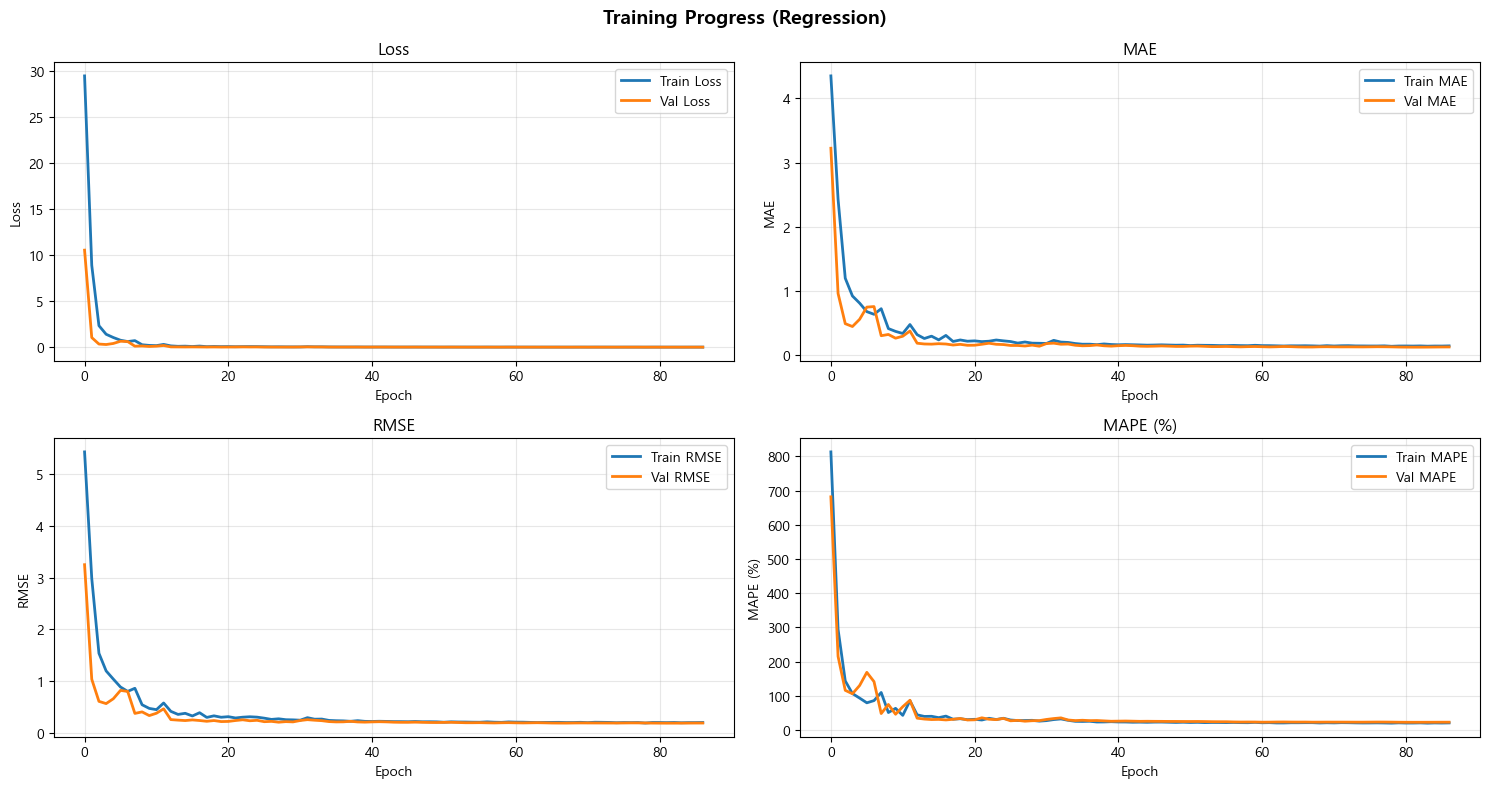

[Test]: 100%|██████████| 1/1 [00:00<00:00,  7.74it/s, loss=0.0196, mae=0.0999, rmse=0.1399]



=== 테스트 세트 평가(회귀) ===
Loss: 0.0196
MAE : 0.0999
RMSE: 0.1399
MAPE: 23.07%
R² (Output 1): 0.8336

✓ Predictions denormalized
  Original shape: (241, 1)
  Denormalized shape: (241, 1)

✓ Predictions saved to C:\AIproject\data\output\ph_predictions.csv


(TransformerRegressor(
   (input_proj): Linear(in_features=11, out_features=512, bias=True)
   (pos_encoding): PositionalEncoding(
     (dropout): Dropout(p=0.1, inplace=False)
   )
   (transformer_encoder): TransformerEncoder(
     (layers): ModuleList(
       (0): TransformerEncoderLayer(
         (self_attn): MultiheadAttention(
           (out_proj): NonDynamicallyQuantizableLinear(in_features=512, out_features=512, bias=True)
         )
         (linear1): Linear(in_features=512, out_features=2048, bias=True)
         (dropout): Dropout(p=0.1, inplace=False)
         (linear2): Linear(in_features=2048, out_features=512, bias=True)
         (norm1): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
         (norm2): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
         (dropout1): Dropout(p=0.1, inplace=False)
         (dropout2): Dropout(p=0.1, inplace=False)
       )
     )
     (norm): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
   )
   (head): Sequential(

In [128]:
main()